### Importation des bibliothèques

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, RocCurveDisplay)
from imblearn.over_sampling import SMOTE

import mlflow
import mlflow.sklearn

import warnings
warnings.filterwarnings('ignore')

C:\Users\COCO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
import os
print(os.getcwd())

c:\Users\COCO\Downloads\Projet_5DLA_Calixte_NGUEMO_et_Corelia_Wildervia\Projet_5DLA_Calixte_NGUEMO_et_Corelia_Wildervia


In [14]:
import os

path = r'C:\Users\COCO\Downloads\Projet_5DLA_Calixte_NGUEMO_et_Corelia_Wildervia\Projet_5DLA_Calixte_NGUEMO_et_Corelia_Wildervia'
print(os.listdir(path))

['.gitignore', 'config.yaml', 'data', 'docker-compose.yml', 'Dockerfile', 'Projet_MLops.ipynb', 'readme.md', 'requirements.txt', 'train.py']


### Chargement des données

In [15]:
import pandas as pd

df = pd.read_csv(r'C:\Users\COCO\Downloads\Projet_5DLA_Calixte_NGUEMO_et_Corelia_Wildervia\Projet_5DLA_Calixte_NGUEMO_et_Corelia_Wildervia\data\creditcard.csv')

print(f"Shape : {df.shape}")
print(df.head())


Shape : (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26

### Étape 1 — Analyse exploratoire (EDA)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [17]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Class
0    284315
1       492
Name: count, dtype: int64

Taux de fraude : 0.173 %


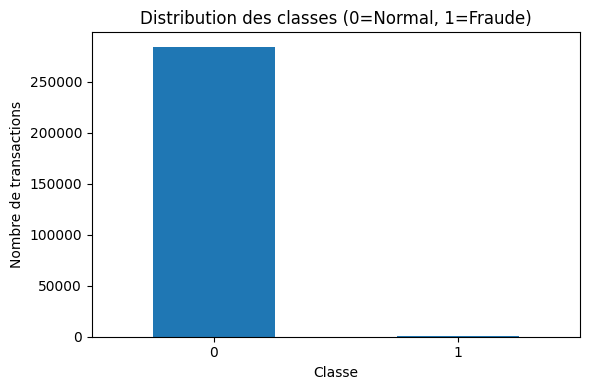

In [18]:
# Déséquilibre des classes
print(df['Class'].value_counts())
print(f"\nTaux de fraude : {df['Class'].mean()*100:.3f} %")

df['Class'].value_counts().plot(kind='bar', figsize=(6, 4))
plt.title('Distribution des classes (0=Normal, 1=Fraude)')
plt.xlabel('Classe')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

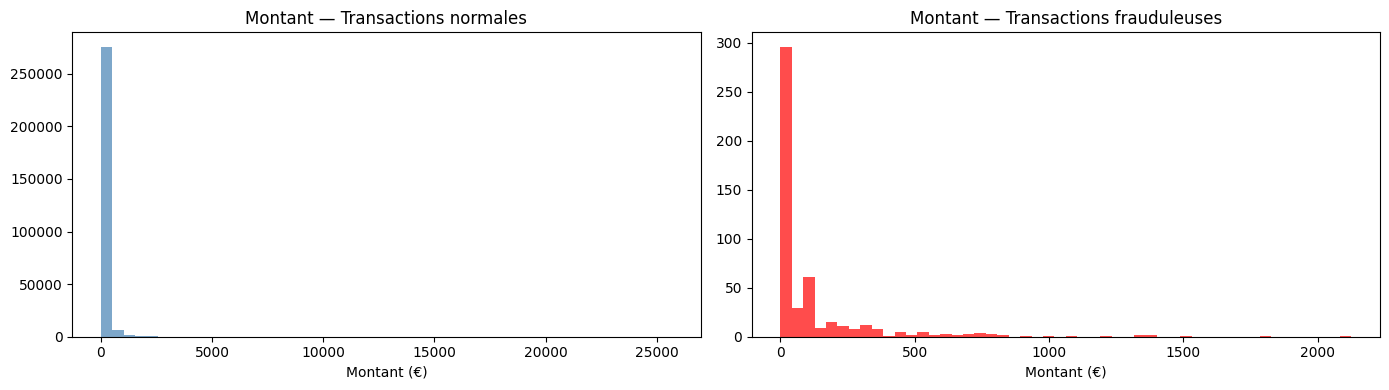

In [19]:
# Distribution du montant par classe
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Montant — Transactions normales')
axes[0].set_xlabel('Montant (€)')

axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='red', alpha=0.7)
axes[1].set_title('Montant — Transactions frauduleuses')
axes[1].set_xlabel('Montant (€)')

plt.tight_layout()
plt.show()

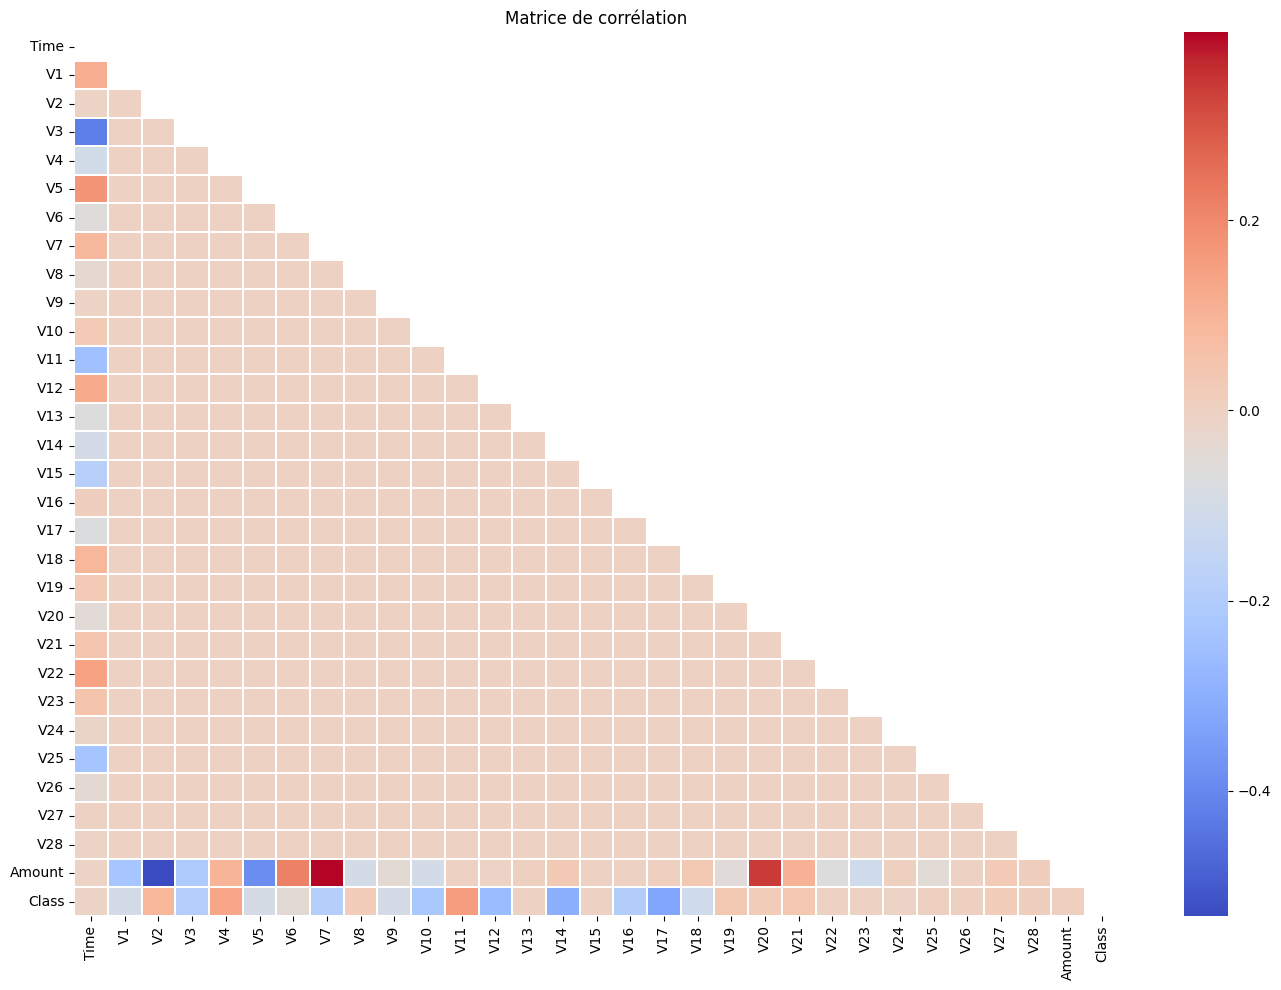

In [20]:
# Matrice de corrélation
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', fmt='.1f', annot=False, linewidths=0.3)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

### Étape 2 — Nettoyage et préparation des données

In [21]:
# Vérification des valeurs manquantes
print("Valeurs manquantes :")
print(df.isnull().sum().sum(), "au total")

# Vérification du seuil (Data Quality Gate)
missing_rate = df.isnull().mean().max()
if missing_rate > 0.05:
    raise ValueError(f"Pipeline bloqué : taux de valeurs manquantes = {missing_rate:.2%} > 5%")
else:
    print(f"Qualité des données OK (manquants : {missing_rate:.2%})")

Valeurs manquantes :
0 au total
Qualité des données OK (manquants : 0.00%)


In [22]:
# Normalisation de Time et Amount (les seules features non-PCA)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

df = df.drop(columns=['Time', 'Amount'])
print("Normalisation effectuée")
df.head()

Normalisation effectuée


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [23]:
# Séparation des features et de la cible
X = df.drop(columns=['Class'])
y = df['Class']

# Split stratifié : 70% train / 15% val / 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3,
                                                     stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5,
                                                  stratify=y_temp, random_state=42)

print(f"Train : {X_train.shape[0]} lignes | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")
print(f"Fraudes train : {y_train.sum()} | val : {y_val.sum()} | test : {y_test.sum()}")

Train : 199364 lignes | Val : 42721 | Test : 42722
Fraudes train : 344 | val : 74 | test : 74


In [24]:
# Gestion du déséquilibre avec SMOTE (sur le train uniquement)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Après SMOTE — Train : {X_train_res.shape[0]} lignes")
print(f"Fraudes : {y_train_res.sum()} | Normal : {(y_train_res==0).sum()}")

Après SMOTE — Train : 398040 lignes
Fraudes : 199020 | Normal : 199020


### Étape 3 — Entraînement et comparaison des modèles

In [25]:
mlflow.set_experiment("fraud-detection-mlops")

def evaluate(model, X_v, y_v, model_name):
    y_proba = model.predict_proba(X_v)[:, 1]
    y_pred  = model.predict(X_v)
    auc_roc = roc_auc_score(y_v, y_proba)
    pr_auc  = average_precision_score(y_v, y_proba)
    print(f"\n--- {model_name} ---")
    print(f"ROC-AUC : {auc_roc:.4f} | PR-AUC : {pr_auc:.4f}")
    print(classification_report(y_v, y_pred, target_names=['Normal', 'Fraude']))
    return auc_roc, pr_auc, y_proba

2026/03/28 04:04:35 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/28 04:04:35 INFO mlflow.store.db.utils: Updating database tables
2026/03/28 04:04:39 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection-mlops' does not exist. Creating a new experiment.


In [26]:
# Modèle 1 : Régression Logistique
with mlflow.start_run(run_name="LogisticRegression"):
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(X_train_res, y_train_res)

    auc, prauc, _ = evaluate(lr, X_val, y_val, "Régression Logistique")

    mlflow.log_param("model",        "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("smote",        True)
    mlflow.log_metric("roc_auc",     auc)
    mlflow.log_metric("pr_auc",      prauc)
    mlflow.sklearn.log_model(lr, "model")

2026/03/28 04:04:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



--- Régression Logistique ---
ROC-AUC : 0.9662 | PR-AUC : 0.6312
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     42647
      Fraude       0.06      0.88      0.12        74

    accuracy                           0.98     42721
   macro avg       0.53      0.93      0.55     42721
weighted avg       1.00      0.98      0.99     42721



2026/03/28 04:04:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [27]:
# Modèle 2 : Random Forest
with mlflow.start_run(run_name="RandomForest"):
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
    rf.fit(X_train_res, y_train_res)

    auc, prauc, _ = evaluate(rf, X_val, y_val, "Random Forest")

    mlflow.log_param("model",         "RandomForest")
    mlflow.log_param("n_estimators",  100)
    mlflow.log_param("class_weight",  "balanced")
    mlflow.log_param("smote",         True)
    mlflow.log_metric("roc_auc",      auc)
    mlflow.log_metric("pr_auc",       prauc)
    mlflow.sklearn.log_model(rf, "model")

2026/03/28 04:07:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 04:07:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



--- Random Forest ---
ROC-AUC : 0.9380 | PR-AUC : 0.8209
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42647
      Fraude       0.84      0.76      0.79        74

    accuracy                           1.00     42721
   macro avg       0.92      0.88      0.90     42721
weighted avg       1.00      1.00      1.00     42721



In [28]:
# Modèle 3 : Isolation Forest (non supervisé)
with mlflow.start_run(run_name="IsolationForest"):
    iso = IsolationForest(contamination=0.002, random_state=42, n_jobs=-1)
    iso.fit(X_train)

    preds_iso = (iso.predict(X_val) == -1).astype(int)
    auc_iso   = roc_auc_score(y_val, preds_iso)
    prauc_iso = average_precision_score(y_val, preds_iso)

    print("\n--- Isolation Forest ---")
    print(f"ROC-AUC : {auc_iso:.4f} | PR-AUC : {prauc_iso:.4f}")
    print(classification_report(y_val, preds_iso, target_names=['Normal', 'Fraude']))

    mlflow.log_param("model",         "IsolationForest")
    mlflow.log_param("contamination", 0.002)
    mlflow.log_metric("roc_auc",      auc_iso)
    mlflow.log_metric("pr_auc",       prauc_iso)


--- Isolation Forest ---
ROC-AUC : 0.6276 | PR-AUC : 0.0608
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42647
      Fraude       0.23      0.26      0.24        74

    accuracy                           1.00     42721
   macro avg       0.62      0.63      0.62     42721
weighted avg       1.00      1.00      1.00     42721



### Étape 4 — Évaluation finale du meilleur modèle


--- Random Forest — TEST ---
ROC-AUC : 0.9597 | PR-AUC : 0.8356
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42648
      Fraude       0.88      0.80      0.84        74

    accuracy                           1.00     42722
   macro avg       0.94      0.90      0.92     42722
weighted avg       1.00      1.00      1.00     42722



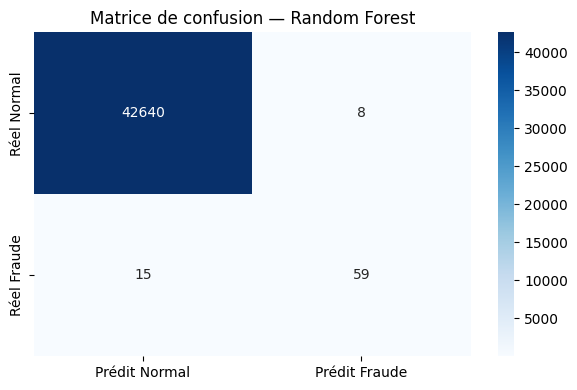

In [ ]:
# Meilleur modèle : Random Forest évaluation sur le test set
auc_test, prauc_test, y_proba_test = evaluate(rf, X_test, y_test, "Random Forest — TEST")

# Matrice de confusion
cm = confusion_matrix(y_test, rf.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Normal', 'Prédit Fraude'],
            yticklabels=['Réel Normal', 'Réel Fraude'])
plt.title('Matrice de confusion — Random Forest')
plt.tight_layout()
plt.show()

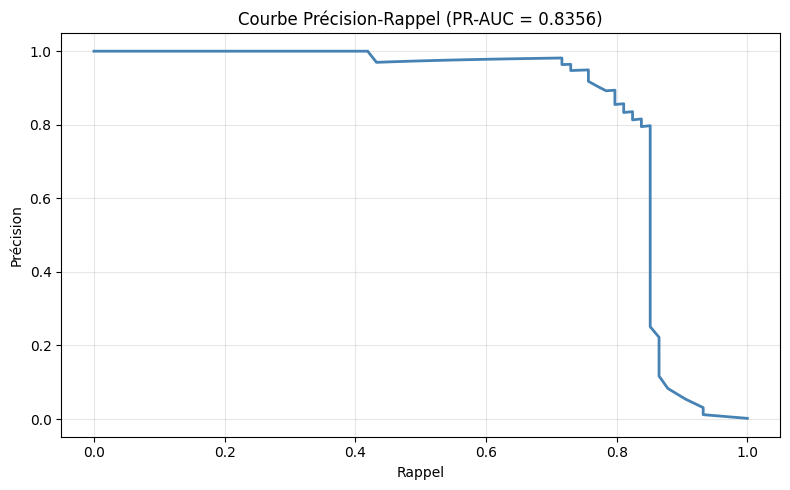

In [30]:
# Courbe Précision-Rappel
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_test)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='steelblue', lw=2)
plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.title(f'Courbe Précision-Rappel (PR-AUC = {prauc_test:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

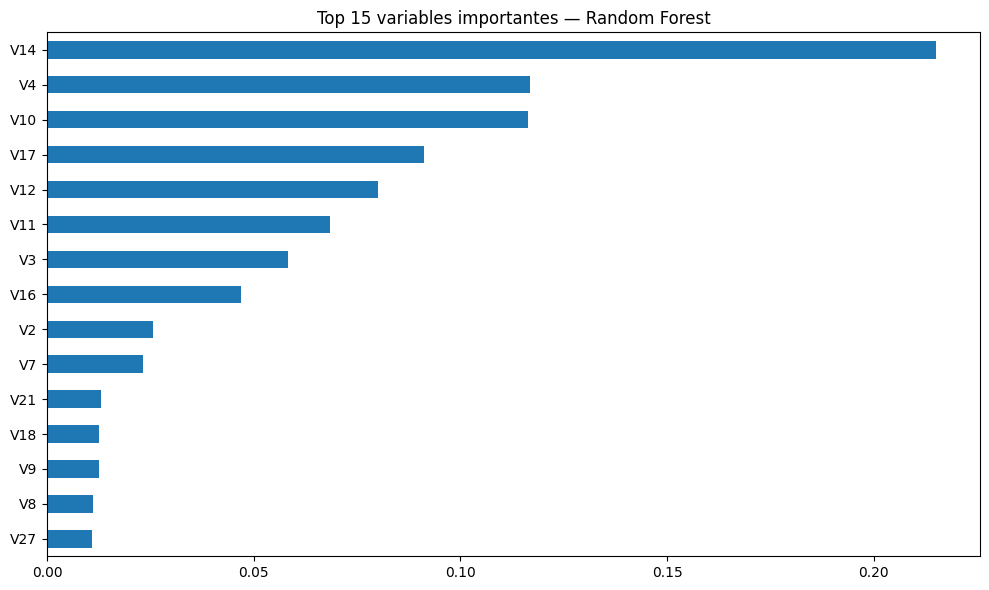

In [31]:
# Importance des variables
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().tail(15).plot(kind='barh', figsize=(10, 6))
plt.title('Top 15 variables importantes — Random Forest')
plt.tight_layout()
plt.show()

### Étape 5 — Détection de dérive des données

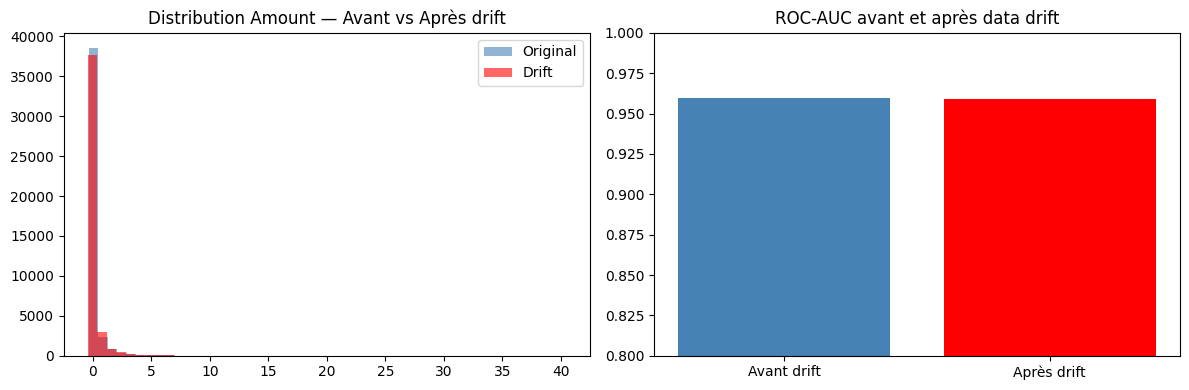

ROC-AUC avant drift : 0.9597
ROC-AUC après drift : 0.9592
Pas de dérive significative détectée


In [32]:
# Simulation de data drift (après t0)
df_drift = X_test.copy()
n_drift   = int(len(df_drift) * 0.20)
idx_drift = np.random.choice(df_drift.index, n_drift, replace=False)

# Amount × 1.3 sur 20% des transactions
df_drift.loc[idx_drift, 'Amount_scaled'] *= 1.3

# Missing rate : 0% → 5% sur V1
idx_missing = np.random.choice(df_drift.index, int(len(df_drift)*0.05), replace=False)
df_drift.loc[idx_missing, 'V1'] = np.nan
df_drift = df_drift.fillna(df_drift.median())

# Comparaison des distributions avant/après drift
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_test['Amount_scaled'], bins=50, alpha=0.6, label='Original', color='steelblue')
axes[0].hist(df_drift['Amount_scaled'], bins=50, alpha=0.6, label='Drift', color='red')
axes[0].set_title('Distribution Amount — Avant vs Après drift')
axes[0].legend()

# Performance après drift
y_pred_drift = rf.predict(df_drift)
auc_drift    = roc_auc_score(y_test, rf.predict_proba(df_drift)[:, 1])
axes[1].bar(['Avant drift', 'Après drift'], [auc_test, auc_drift], color=['steelblue','red'])
axes[1].set_title('ROC-AUC avant et après data drift')
axes[1].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

print(f"ROC-AUC avant drift : {auc_test:.4f}")
print(f"ROC-AUC après drift : {auc_drift:.4f}")
if auc_test - auc_drift > 0.01:
    print("ALERTE : dérive détectée — dégradation > 1%")
else:
    print("Pas de dérive significative détectée")

### Conclusion

In [35]:
print("=" * 60)
print("  RÉSULTATS : FRAUDE BANCAIRE PAR CALIXTE NGUEMO ET CORELIA WILDERVIA")
print("=" * 60)
print(f"  Dataset        : Credit Card Fraud Detection")
print(f"  Transactions   : 284 807 | Fraudes : 492 (0.17%)")
print()
print(f"  Modèles testés :")
print(f"  - Régression Logistique")
print(f"  - Random Forest  ")
print(f"  - Isolation Forest")
print()
print(f" Modèle Champion : Random Forest")
print(f"  ROC-AUC (test)  : {auc_test:.4f}")
print(f"  PR-AUC  (test)  : {prauc_test:.4f}")
print()
print("  RECOMMANDATIONS :")
print("  - Déployer Random Forest via FastAPI + Docker")
print("  - Surveiller le data drift chaque semaine")
print("  - Recalibrer le seuil de décision selon PR-AUC")
print("  - Réentraîner si ROC-AUC chute de plus de 1%")
print("=" * 60)

  RÉSULTATS : FRAUDE BANCAIRE PAR CALIXTE NGUEMO ET CORELIA WILDERVIA
  Dataset        : Credit Card Fraud Detection
  Transactions   : 284 807 | Fraudes : 492 (0.17%)

  Modèles testés :
  - Régression Logistique
  - Random Forest  
  - Isolation Forest

 Modèle Champion : Random Forest
  ROC-AUC (test)  : 0.9597
  PR-AUC  (test)  : 0.8356

  RECOMMANDATIONS :
  - Déployer Random Forest via FastAPI + Docker
  - Surveiller le data drift chaque semaine
  - Recalibrer le seuil de décision selon PR-AUC
  - Réentraîner si ROC-AUC chute de plus de 1%
